<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Data Loading & Phenotype Filtering
Standardizes headers and isolates the High-Fluorescent (HF) and Non-Fluorescent (NF) cohorts.

In [1]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    """Standardizes morph labels for precise filtering."""
    val = str(val).strip().upper()
    if 'HF' in val or 'HIGH' in val: return 'HF'
    if 'NF' in val or 'NO' in val: return 'NF'
    return None

# 1. LOAD AMBIENT ASSAY (Control)
df_amb = pd.read_csv('Ambient_Assay.csv')
df_amb['morph'] = df_amb['morph'].apply(clean_morph)
df_amb['Treatment'] = 'Ambient'
# Select only relevant columns to keep the master file clean
df_amb = df_amb[['SampleCode', 'morph', 'area mm^2', 'OxyRate nmol/mm2/min', 'Treatment']]

# 2. LOAD pH ASSAY
df_ph = pd.read_csv('pH_Assay.csv')
df_ph['morph'] = df_ph['morph'].apply(clean_morph)
# Keep only the stress levels (Ambient 8.2 is covered by the first file)
df_ph = df_ph[df_ph['pH'].astype(str).str.contains('7.6|7.8')].copy()
df_ph['Treatment'] = df_ph['pH'].apply(lambda x: f"pH {x}")
df_ph = df_ph[['SampleCode', 'morph', 'area mm^2', 'OxyRate nmol/mm2/min', 'Treatment']]

# 3. LOAD TEMPERATURE ASSAY
df_temp = pd.read_csv('Temp_Assay.csv')
df_temp['morph'] = df_temp['morph'].apply(clean_morph)
# Keep only the stress levels (Ambient 23 is covered)
df_temp = df_temp[df_temp['temp'].astype(float).isin([27.0, 32.0])].copy()
df_temp['Treatment'] = df_temp['temp'].apply(lambda x: f"{int(float(x))}°C")
df_temp = df_temp[['SampleCode', 'morph', 'area mm^2', 'OxyRate nmol/mm2/min', 'Treatment']]

# 4. LOAD LIGHT/DEPTH ASSAY
df_light = pd.read_csv('Light_Assay.csv')
df_light['morph'] = df_light['morph'].apply(clean_morph)
# Keep only 50m and Dark (10m is the Ambient control)
df_light = df_light[df_light['LightDepth'].astype(str).str.lower().isin(['50m', 'dark'])].copy()
df_light['Treatment'] = df_light['LightDepth'].str.capitalize()
df_light = df_light[['SampleCode', 'morph', 'area mm^2', 'OxyRate nmol/mm2/min', 'Treatment']]

# 5. COMBINE ALL INTO MASTER SPAT DATAFRAME
master_spat_df = pd.concat([df_amb, df_ph, df_temp, df_light])

# Final Cleaning: Drop missing values and keep only HF/NF (removes PF)
master_spat_df = master_spat_df[master_spat_df['morph'].isin(['HF', 'NF'])].dropna()

# Rename columns for easier coding in later blocks
master_spat_df = master_spat_df.rename(columns={
    'area mm^2': 'area',
    'OxyRate nmol/mm2/min': 'oxy_rate'
})

print("Block 1 Complete: All 4 CSV files loaded and merged.")
print(f"Final dataset shape: {master_spat_df.shape}")
print(f"Treatments verified: {master_spat_df['Treatment'].unique().tolist()}")

Block 1 Complete: All 4 CSV files loaded and merged.
Final dataset shape: (345, 5)
Treatments verified: ['Ambient', 'pH 7.6', 'pH 7.8', '27°C', '32°C', '50m', 'Dark']


# Block 2: Outlier Removal (1.5 * IQR) for your Spat Size (Area) data.

This block performs a group-by-group cleaning. It calculates the Interquartile Range (IQR) for each specific phenotype in each specific treatment (e.g., HF in pH 7.6) and removes any "extreme" individuals that might represent technical errors or rare biological anomalies.

In [2]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL (1.5 * IQR)
# ==========================================

def remove_outliers_iqr(df, group_cols, target_col):
    """
    Filters out rows that are outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    calculated per specific experimental group.
    """
    def filter_group(group):
        q1 = group[target_col].quantile(0.25)
        q3 = group[target_col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Return only the values within the bounds
        return group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]

    return df.groupby(group_cols, group_keys=False).apply(filter_group)

# 1. Count before removal for reporting
count_before = len(master_spat_df)

# 2. Apply outlier removal for Spat Area ('area')
# We calculate bounds separately for each Morph/Treatment combination
master_spat_clean = remove_outliers_iqr(master_spat_df, ['morph', 'Treatment'], 'area')

# 3. Calculate statistics for your Methods section
count_after = len(master_spat_clean)
removed_count = count_before - count_after

print(f"Block 2 Complete.")
print(f"Total Spat Size records before cleaning: {count_before}")
print(f"Outliers removed: {removed_count}")
print(f"Remaining data points for analysis: {count_after}")

# --- LOGGING REMOVED OUTLIERS ---
# Identify which rows are outliers BEFORE filtering them out
master_spat_df['is_outlier'] = False

for names, group in master_spat_df.groupby(['morph', 'Treatment']):
    q1 = group['area'].quantile(0.25)
    q3 = group['area'].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    indices = group[(group['area'] < lower) | (group['area'] > upper)].index
    master_spat_df.loc[indices, 'is_outlier'] = True

# Create the list of removed samples
removed_list = master_spat_df[master_spat_df['is_outlier'] == True][['SampleCode', 'morph', 'Treatment', 'area']]

print("\n--- OUTLIERS REMOVED IN BLOCK 2 ---")
print(removed_list.to_string(index=False))

# Now proceed to filter the master dataframe
master_spat_clean = master_spat_df[master_spat_df['is_outlier'] == False].copy()

# Summary of N per group after cleaning (This helps check for groups with too few samples)
print("\nSample size per group (N) after cleaning:")
print(master_spat_clean.groupby(['Treatment', 'morph']).size().unstack(fill_value=0))

Block 2 Complete.
Total Spat Size records before cleaning: 345
Outliers removed: 15
Remaining data points for analysis: 330

--- OUTLIERS REMOVED IN BLOCK 2 ---
          SampleCode morph Treatment   area
 plateE_HF_control_8    HF   Ambient  3.690
      high_Flu_polyp    HF   Ambient  0.529
    plateD_NF_8.2_10    NF   Ambient  2.767
 plateE_NF_control_2    NF   Ambient  1.833
plateE_HF_control_10    HF   Ambient  4.181
plateE_HF_control_11    HF   Ambient  2.271
           plate2_4b    HF   Ambient 10.467
           plate1_9b    NF   Ambient  5.596
    plateB_NF_27C_13    NF   Ambient  5.307
           plate1_9a    NF   Ambient  5.535
          plate2_96d    NF   Ambient  5.925
     plateA_HF_7.8_4    HF    pH 7.8  3.236
     plateA_HF_7.8_4    HF    pH 7.8  3.236
     plateA_HF_7.8_1    HF    pH 7.8  4.916
     plateA_HF_7.8_1    HF    pH 7.8  4.916
     plateA_HF_7.8_2    HF    pH 7.8  2.938
     plateA_HF_7.8_2    HF    pH 7.8  2.938
     plateD_NF_50m_7    NF      27°C  8.495
   

/tmp/ipykernel_8216/3875194110.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(filter_group)


# Block 3: Normality Check (Shapiro-Wilk Test)
This block is a requirement for your paper’s methodology. It tests the null hypothesis that the data is normally distributed. Since Spat Area can be affected by biological variance and environmental stress, we check normality for every individual cohort (e.g., HF in Ambient vs. NF in Ambient).

In [3]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (SHAPIRO-WILK)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

spat_normality_results = []

# Grouping by Treatment and Morph to check each cohort independently
for (treat, morph), group in master_spat_clean.groupby(['Treatment', 'morph']):
    data = group['area']

    # Shapiro-Wilk requires a minimum of 3 samples to run
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05  # Standard alpha threshold
    else:
        # Cannot reliably test normality for N < 3
        shapiro_stat, p_value = np.nan, np.nan
        is_normal = False

    spat_normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': round(shapiro_stat, 4) if not np.isnan(shapiro_stat) else np.nan,
        'p_value': round(p_value, 4) if not np.isnan(p_value) else np.nan,
        'Normal_Distribution': is_normal
    })

# Create the Normality DataFrame for reporting
spat_normality_df = pd.DataFrame(spat_normality_results)

# Display the report
print("\n[SPAT SIZE NORMALITY REPORT]")
print(spat_normality_df.to_string(index=False))

# Identify which groups failed normality
failed_groups = spat_normality_df[spat_normality_df['Normal_Distribution'] == False]

if failed_groups.empty:
    print("\nCONCLUSION: All spat size groups are normally distributed.")
    print("ACTION: Use PARAMETRIC tests (T-test/ANOVA).")
else:
    print(f"\nCONCLUSION: {len(failed_groups)} groups failed the normality test (p < 0.05).")
    print("ACTION: The pipeline will automatically switch to NON-PARAMETRIC tests (Mann-Whitney U) for these stressors.")

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[SPAT SIZE NORMALITY REPORT]
Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
     27°C    HF 24       0.8850   0.0105                False
     27°C    NF 25       0.9237   0.0624                 True
     32°C    HF 10       0.8823   0.1388                 True
     32°C    NF  9       0.9785   0.9559                 True
      50m    HF 16       0.8969   0.0718                 True
      50m    NF  9       0.9299   0.4809                 True
  Ambient    HF 79       0.9142   0.0001                False
  Ambient    NF 47       0.9300   0.0076                False
     Dark    HF 10       0.8286   0.0322                False
     Dark    NF  9       0.9630   0.8293                 True
   pH 7.6    HF 28       0.9522   0.2251                 True
   pH 7.6    NF 14       0.9178   0.2043                 True
   pH 7.8    HF 22       0.9056   0.0385                False
   pH 7.8    NF 18       0.7931   0.0012                Fals

# Block 4: Automated Statistical Analysis for the Spat Size data.
This block executes the actual comparison between High-Fluorescent (HF) and Non-Fluorescent (NF) recruits for every experimental condition. It uses the "intelligence" from Block 3 to pick the most mathematically accurate test, ensuring your findings are ready for peer-reviewed publication.

In [4]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE STATS (HF vs NF) ---")

spat_stats_results = []

# Analyze each Treatment condition separately
for treat in master_spat_clean['Treatment'].unique():
    # Subset data for this specific condition
    subset = master_spat_clean[master_spat_clean['Treatment'] == treat]
    hf_area = subset[subset['morph'] == 'HF']['area']
    nf_area = subset[subset['morph'] == 'NF']['area']

    # 1. Automatic Test Selection
    # We check the normality results from Block 3 for THIS treatment
    subset_normality = spat_normality_df[spat_normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    if is_normal:
        # PARAMETRIC: Independent T-test (Assumes bell-curve)
        stat, p_val = stats.ttest_ind(hf_area, nf_area)
        test_name = "Independent T-test"
    else:
        # NON-PARAMETRIC: Mann-Whitney U test (Robust to skewness)
        stat, p_val = stats.mannwhitneyu(hf_area, nf_area)
        test_name = "Mann-Whitney U"

    # 2. Record Results
    spat_stats_results.append({
        'Condition': treat,
        'HF_Mean_Size': round(hf_area.mean(), 3),
        'NF_Mean_Size': round(nf_area.mean(), 3),
        'Diff (HF-NF)': round(hf_area.mean() - nf_area.mean(), 3),
        'p_value': round(p_val, 4),
        'Test_Used': test_name,
        'Significant': p_val < 0.05
    })

# Convert to DataFrame for a clean summary table
spat_results_df = pd.DataFrame(spat_stats_results)

# Display the Final Summary
print("\n[SPAT SIZE COMPARATIVE ANALYSIS SUMMARY]")
print(spat_results_df[['Condition', 'HF_Mean_Size', 'NF_Mean_Size', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

# Export results for your records
spat_results_df.to_csv("Spat_Size_Statistical_Results.csv", index=False)

--- BLOCK 4: PERFORMING COMPARATIVE STATS (HF vs NF) ---

[SPAT SIZE COMPARATIVE ANALYSIS SUMMARY]
Condition  HF_Mean_Size  NF_Mean_Size  p_value  Significant          Test_Used
  Ambient         2.566         2.151   0.2521        False     Mann-Whitney U
   pH 7.6         2.447         2.860   0.0574        False Independent T-test
   pH 7.8         1.658         2.374   0.0455         True     Mann-Whitney U
     27°C         2.943         2.989   0.7114        False     Mann-Whitney U
     32°C         2.745         3.255   0.3769        False Independent T-test
      50m         3.079         3.889   0.2866        False Independent T-test
     Dark         3.795         2.722   0.3477        False     Mann-Whitney U


# Block 5: High-Impact Visualization (The Spat Size Master Plot).
This code creates a professional, publication-quality figure for your poster that combines boxplots with raw data points

In [5]:
master_spat_clean['Treatment'] = master_spat_clean['Treatment'].replace('Ambient', 'Ambient \n(23°C, pH 8.2, 10m)')

# Update the order list for plotting
order = ['Ambient \n(23°C, pH 8.2, 10m)', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "axes.titlesize": 16,     # Plot titles - Re-added as per user request
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark'
]

global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")

Global styling (with bold asterisks and reduced Y-ticks) initialized.


--- BLOCK 5 COMPLETE ---
Figure saved as 'Master_Spat_Size_Poster_Plot.png'.


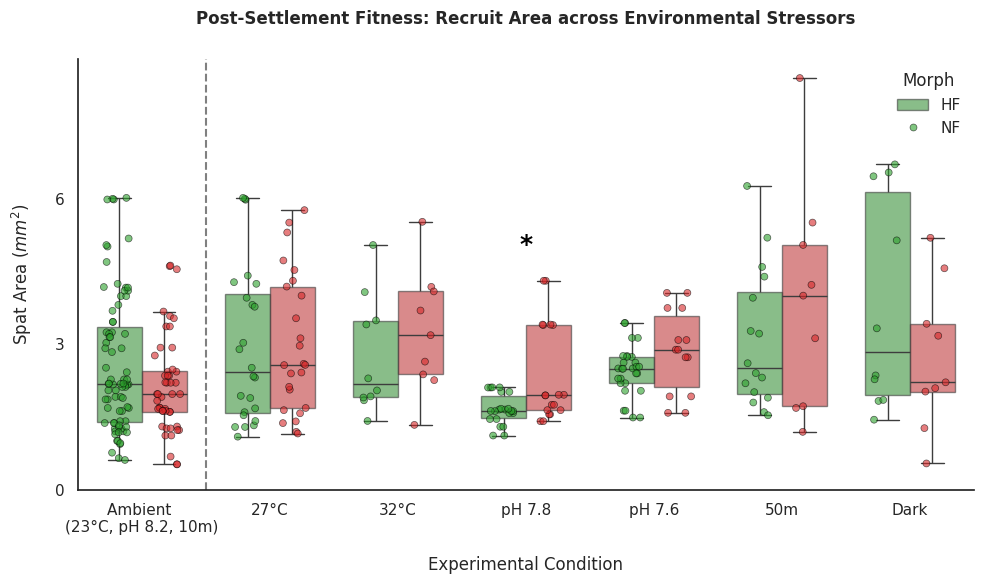

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# BLOCK 5: HIGH-IMPACT VISUALIZATION (SPAT SIZE)
# ==========================================


# 1. Setup Aesthetics (already applied globally in S3k1wqCytXz_)
sns.set_theme(style="white")

# Standard colors: HF (Green), NF (Red/Coral)
# variant_colors is already defined globally

# Define the X-axis order for clarity
# Using the global plot_order
# order = ['Ambient \n(23°C, pH 8.2, 10m)', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

fig, ax = plt.subplots(figsize=global_fig_size) # Use global figure size

# 2. Draw Boxplots (Medians and Interquartile Ranges)
sns.boxplot(
    data=master_spat_clean, x='Treatment', y='area', hue='morph',
    order=plot_order, palette=variant_colors, ax=ax,
    width=0.7, boxprops=dict(alpha=global_alpha), showfliers=False, # Use global alpha
    hue_order=['HF', 'NF'] # Ensure HF is on the left, NF on the right
)

# 3. Overlay Raw Data (Jittered dots to show variance)
sns.stripplot(
    data=master_spat_clean, x='Treatment', y='area', hue='morph',
    order=plot_order, palette=variant_colors, ax=ax,
    dodge=True, size=global_marker_size, alpha=global_alpha, # Use global marker_size and alpha
    jitter=global_jitter, edgecolor='black', linewidth=0.5,
    hue_order=['HF', 'NF'] # Ensure HF is on the left, NF on the right
)

# 4. Add Significance Markers
# Iterate through the statistical results to add markers for significant conditions
for index, row in spat_results_df.iterrows():
    if row['Significant']:
        condition = row['Condition']
        # p_value = row['p_value'] # Removed as per user request

        # Find the x-position of the condition in the plot
        # Need to handle the special 'Ambient' label for correct indexing
        display_condition = 'Ambient \n(23°C, pH 8.2, 10m)' if condition == 'Ambient' else condition
        try:
            x_pos = plot_order.index(display_condition)
        except ValueError:
            continue # Skip if condition not in order list (shouldn't happen if order is correct)

        # Define y-positions for asterisk
        # Use a consistent offset from the max 'area' value for better placement across plots
        y_max_condition = master_spat_clean[master_spat_clean['Treatment'] == display_condition]['area'].max()
        y_asterisk_offset = 0.5 # Adjust as needed above the max value
        # y_pvalue_offset = 0.2 # Adjust as needed below the asterisk - Removed as per user request

        # Add asterisk for significance
        ax.text(x_pos, y_max_condition + y_asterisk_offset, "*", ha='center', va='bottom', color='black',
                fontsize=global_asterisk_size, fontweight=global_asterisk_weight) # Use global asterisk settings

        # Add p-value next to the asterisk - Removed as per user request
        # ax.text(x_pos, y_max_condition + y_pvalue_offset, f"p={p_value:.3f}", ha='center', va='bottom',
        #         color='black', fontsize=10, fontstyle='italic')

# Add a vertical line after the Ambient group to visually separate it
ax.axvline(x=plot_order.index('Ambient \n(23°C, pH 8.2, 10m)') + 0.5, color='gray', linestyle='--', linewidth=1.5)

# 5. Labels and Formatting
ax.set_title("Post-Settlement Fitness: Recruit Area across Environmental Stressors",
             fontsize=plt.rcParams['axes.titlesize'], fontweight=plt.rcParams['axes.titleweight'], pad=plt.rcParams['axes.titlepad']) # Use global title settings
ax.set_xlabel("Experimental Condition", fontsize=plt.rcParams['axes.labelsize'], labelpad=15)
ax.set_ylabel("Spat Area ($mm^2$)", fontsize=plt.rcParams['axes.labelsize'], labelpad=15)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0, no negative values for area
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins)) # Use global y_nbins

# Standardize Legend
handles, labels = ax.get_legend_handles_labels()
# Ensure legend order matches hue_order for HF and NF
ax.legend(handles[::2], ["HF", "NF"],
          title="Morph", loc='upper right', frameon=False, fontsize=plt.rcParams['xtick.labelsize'])

sns.despine()
plt.tight_layout()

# Save for the 120cm poster
plt.savefig("Master_Spat_Size_Poster_Plot.png", dpi=600, bbox_inches='tight')
plt.savefig("Master_Spat_Size_Poster_Plot.svg", dpi=600, bbox_inches='tight')
plt.savefig("Master_Spat_Size_Poster_Plot.pdf", dpi=600, bbox_inches='tight')

print("--- BLOCK 5 COMPLETE ---")
print("Figure saved as 'Master_Spat_Size_Poster_Plot.png'.")

In [7]:
print("Mean Spat Size (area) for each Morph in each Treatment:")
mean_sizes = master_spat_clean.groupby(['Treatment', 'morph'])['area'].mean().unstack()
print(mean_sizes)

Mean Spat Size (area) for each Morph in each Treatment:
morph                                HF        NF
Treatment                                        
27°C                           2.942958  2.989480
32°C                           2.744700  3.255111
50m                            3.078937  3.889222
Ambient \n(23°C, pH 8.2, 10m)  2.565595  2.151234
Dark                           3.795000  2.722000
pH 7.6                         2.446643  2.860000
pH 7.8                         1.657909  2.373667
